In [ ]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(wine.feature_names)

print("\nClasses:")
print(wine.target_names)

Dataset shape: (178, 13)
Target shape: (178,)

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Classes:
['class_0' 'class_1' 'class_2']


In [ ]:
# Create a DataFrame

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

print("First 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df["target"].value_counts())

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (142, 13)
Testing data shape: (36, 13)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data standardized successfully.")

Data standardized successfully.


In [ ]:
def create_model(learning_rate):
    model = Sequential([
        Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(3, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def forward_propagation(model, X):
    predictions = model(X, training=False)
    return predictions

model = create_model(0.001)

sample_data = X_train[:5]

predictions = forward_propagation(
    model,
    sample_data
)

print("Forward Propagation Output:")
print(predictions.numpy())

print("\nOutput shape:")
print(predictions.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Forward Propagation Output:
[[0.36458325 0.18344273 0.45197406]
 [0.20104471 0.0504273  0.748528  ]
 [0.3034711  0.1770603  0.51946855]
 [0.2622766  0.18308222 0.5546412 ]
 [0.01654858 0.0267257  0.95672566]]

Output shape:
(5, 3)


In [ ]:
def train_one_step(model, X_batch, y_batch, optimizer):

    # Forward propagation
    with tf.GradientTape() as tape:
        predictions = model(X_batch, training=True)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_batch,
            predictions
        )
        loss = tf.reduce_mean(loss)

    # Backpropagation: calculate gradients
    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Update weights and biases
    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return loss

In [ ]:
def train_model(learning_rate, epochs, batch_size=32, verbose=True):

    model = create_model(learning_rate)

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    train_losses = []
    train_accuracies = []

    n_samples = X_train.shape[0]

    for epoch in range(epochs):

        # Shuffle data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0.0

        # Mini-batch training
        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            X_batch = tf.convert_to_tensor(
                X_shuffled[start:end],
                dtype=tf.float32
            )
            y_batch = tf.convert_to_tensor(
                y_shuffled[start:end],
                dtype=tf.int32
            )

            loss = train_one_step(
                model,
                X_batch,
                y_batch,
                optimizer
            )

            epoch_loss += float(loss)

        # Training accuracy
        train_predictions = model(
            X_train,
            training=False
        )

        predicted_classes = tf.argmax(
            train_predictions,
            axis=1
        )

        accuracy = tf.reduce_mean(
            tf.cast(
                tf.equal(
                    predicted_classes,
                    y_train
                ),
                tf.float32
            )
        )

        train_losses.append(epoch_loss)
        train_accuracies.append(float(accuracy))

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"Epoch {epoch + 1:3d}/{epochs} "
                f"- Loss: {epoch_loss:.4f} "
                f"- Accuracy: {accuracy:.4f}"
            )

    return model, train_losses, train_accuracies

In [ ]:
model, losses, accuracies = train_model(
    learning_rate=0.001,
    epochs=100
)

Epoch   1/100 - Loss: 5.9763 - Accuracy: 0.3028
Epoch  10/100 - Loss: 4.5026 - Accuracy: 0.4930
Epoch  20/100 - Loss: 3.2602 - Accuracy: 0.9155
Epoch  30/100 - Loss: 1.6424 - Accuracy: 0.9789
Epoch  40/100 - Loss: 0.7711 - Accuracy: 0.9859
Epoch  50/100 - Loss: 0.4199 - Accuracy: 0.9930
Epoch  60/100 - Loss: 0.3137 - Accuracy: 1.0000
Epoch  70/100 - Loss: 0.2324 - Accuracy: 1.0000
Epoch  80/100 - Loss: 0.1410 - Accuracy: 1.0000
Epoch  90/100 - Loss: 0.1028 - Accuracy: 1.0000
Epoch 100/100 - Loss: 0.0870 - Accuracy: 1.0000


In [ ]:
test_predictions = model(
    X_test,
    training=False
)

test_predicted_classes = tf.argmax(
    test_predictions,
    axis=1
).numpy()

test_accuracy = accuracy_score(
    y_test,
    test_predicted_classes
)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9444


In [ ]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        test_predicted_classes,
        target_names=wine.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



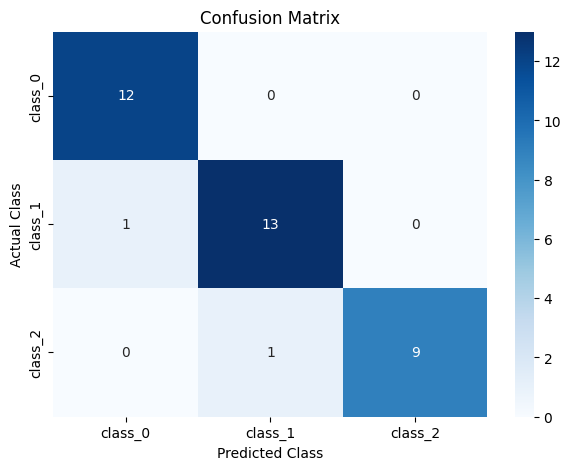

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    test_predicted_classes
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

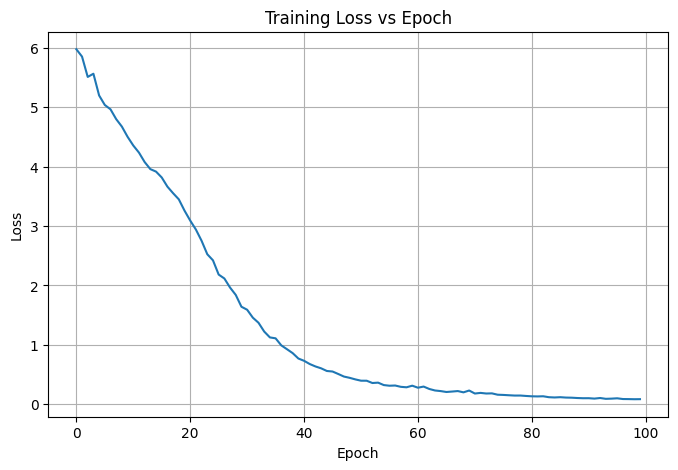

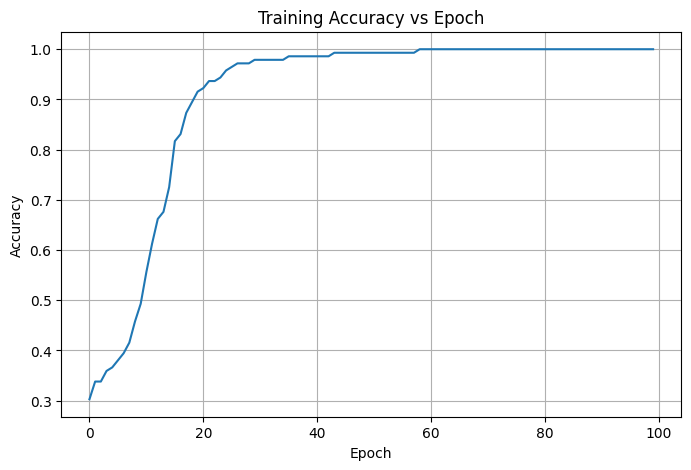

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.grid()
plt.show()

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

learning_rate_results = []

for lr in learning_rates:

    print("\n" + "=" * 60)
    print(f"Learning Rate = {lr}")
    print("=" * 60)

    model_lr, losses_lr, accuracies_lr = train_model(
        learning_rate=lr,
        epochs=100,
        verbose=False
    )

    predictions_lr = model_lr(
        X_test,
        training=False
    )

    predicted_lr = tf.argmax(
        predictions_lr,
        axis=1
    ).numpy()

    test_acc_lr = accuracy_score(
        y_test,
        predicted_lr
    )

    learning_rate_results.append({
        "Learning Rate": lr,
        "Test Accuracy": test_acc_lr
    })

lr_results_df = pd.DataFrame(learning_rate_results)

print("\nLearning Rate Comparison:")
display(lr_results_df)


Learning Rate = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Learning Rate = 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Learning Rate = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Learning Rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Learning Rate Comparison:


,Learning Rate,Test Accuracy
0,0.0001,0.638889
1,0.0010,0.944444
2,0.0100,0.972222
3,0.1000,0.944444


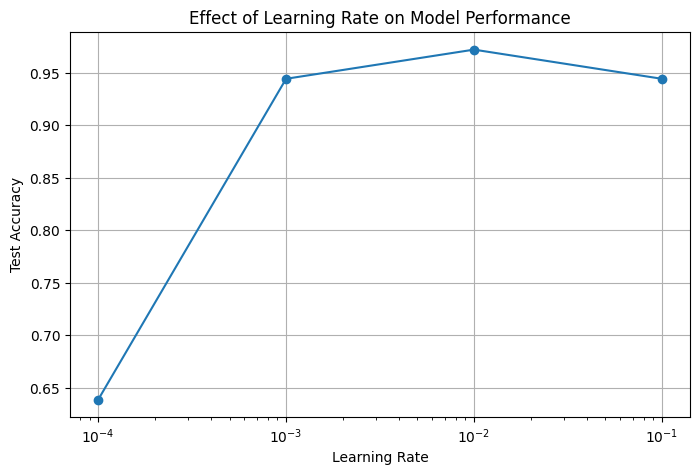

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_results_df["Learning Rate"],
    lr_results_df["Test Accuracy"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Effect of Learning Rate on Model Performance")
plt.grid()
plt.show()

In [ ]:
epoch_values = [10, 25, 50, 100, 200]

epoch_results = []

for epochs in epoch_values:

    print("\n" + "=" * 60)
    print(f"Number of Epochs = {epochs}")
    print("=" * 60)

    model_epoch, losses_epoch, accuracies_epoch = train_model(
        learning_rate=0.001,
        epochs=epochs,
        verbose=False
    )

    predictions_epoch = model_epoch(
        X_test,
        training=False
    )

    predicted_epoch = tf.argmax(
        predictions_epoch,
        axis=1
    ).numpy()

    test_acc_epoch = accuracy_score(
        y_test,
        predicted_epoch
    )

    epoch_results.append({
        "Epochs": epochs,
        "Test Accuracy": test_acc_epoch
    })

epoch_results_df = pd.DataFrame(epoch_results)

print("\nEpoch Comparison:")
display(epoch_results_df)


Number of Epochs = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Number of Epochs = 25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Number of Epochs = 50


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Number of Epochs = 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch Comparison:


,Epochs,Test Accuracy
0,10,0.555556
1,25,0.888889
2,50,0.916667
3,100,0.972222
4,200,0.944444


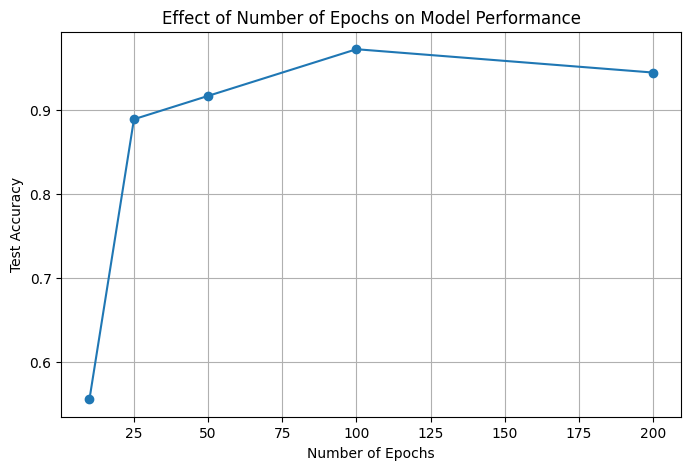

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_results_df["Epochs"],
    epoch_results_df["Test Accuracy"],
    marker="o"
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Epochs on Model Performance")
plt.grid()
plt.show()

In [ ]:
best_lr_row = lr_results_df.loc[
    lr_results_df["Test Accuracy"].idxmax()
]

best_epoch_row = epoch_results_df.loc[
    epoch_results_df["Test Accuracy"].idxmax()
]

print("Best Learning Rate:")
print(best_lr_row)

print("\nBest Number of Epochs:")
print(best_epoch_row)

Best Learning Rate:
Learning Rate    0.010000
Test Accuracy    0.972222
Name: 2, dtype: float64

Best Number of Epochs:
Epochs           100.000000
Test Accuracy      0.972222
Name: 3, dtype: float64
